In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

# Configuration
DATA_FILE = "/home/lucas_takanori/phd/data/subject001_baseline_masked.h5"  # Change this to your data file path
FRAME_SIZE = 50  # 50 samples = 1 second of BP data
plt.style.use('default')


In [2]:
# Load BP data
def load_bp_data(data_file):
    """Load BP signal data from HDF5 file"""
    with h5py.File(data_file, 'r') as f:
        bp_data = f['data']['bp']['signal'][:]
        
        print(f"Data file: {os.path.basename(data_file)}")
        print(f"BP data shape: {bp_data.shape}  # [batch, time_samples]")
        print(f"BP data range: [{bp_data.min():.1f}, {bp_data.max():.1f}] mmHg")
        print(f"Number of possible frames per batch: {bp_data.shape[1] // FRAME_SIZE}")
        
        return bp_data

# Load the data
bp_data = load_bp_data(DATA_FILE)


Data file: subject001_baseline_masked.h5
BP data shape: (50, 867)  # [batch, time_samples]
BP data range: [39.4, 131.0] mmHg
Number of possible frames per batch: 17


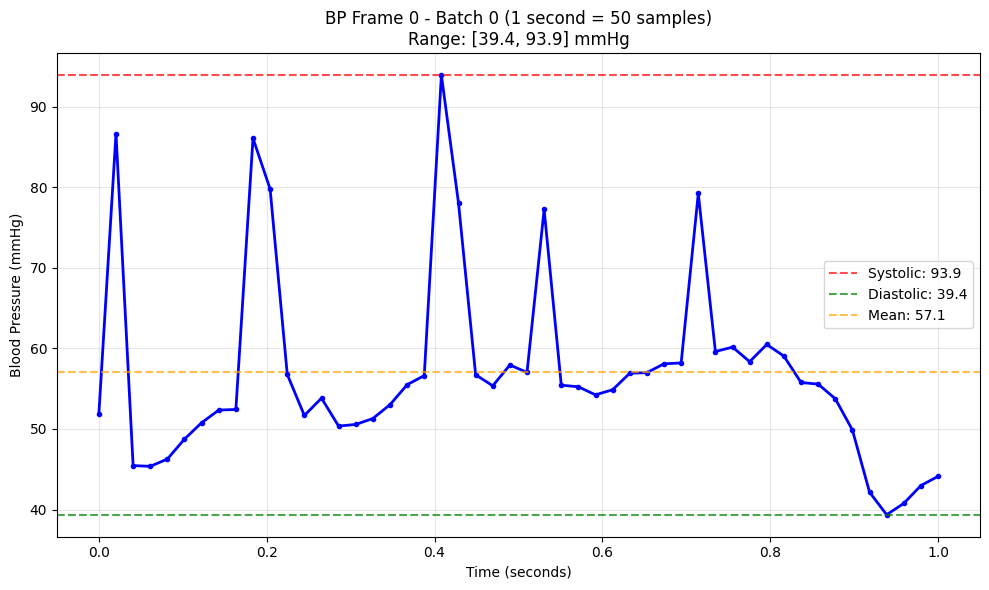

Frame statistics:
  Systolic (max): 93.9 mmHg
  Diastolic (min): 39.4 mmHg
  Mean BP: 57.1 mmHg
  Pulse Pressure: 54.6 mmHg


In [3]:
def plot_bp_frame(bp_data, batch_idx=0, frame_idx=0, figsize=(10, 6)):
    """Plot a single BP frame (50 samples = 1 second)"""
    
    # Calculate start and end indices for the frame
    start_idx = frame_idx * FRAME_SIZE
    end_idx = start_idx + FRAME_SIZE
    
    # Check if frame is valid
    if end_idx > bp_data.shape[1]:
        print(f"Frame {frame_idx} is out of bounds. Max frame index: {bp_data.shape[1] // FRAME_SIZE - 1}")
        return None
    
    # Extract the frame
    bp_frame = bp_data[batch_idx, start_idx:end_idx]
    
    # Create time axis (assuming 50 Hz sampling rate, so 50 samples = 1 second)
    time_axis = np.linspace(0, 1, FRAME_SIZE)  # 0 to 1 second
    
    # Create the plot
    plt.figure(figsize=figsize)
    plt.plot(time_axis, bp_frame, 'b-', linewidth=2, marker='o', markersize=3)
    plt.grid(True, alpha=0.3)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Blood Pressure (mmHg)')
    plt.title(f'BP Frame {frame_idx} - Batch {batch_idx} (1 second = 50 samples)\n'
              f'Range: [{bp_frame.min():.1f}, {bp_frame.max():.1f}] mmHg')
    
    # Add some statistics
    systolic = np.max(bp_frame)
    diastolic = np.min(bp_frame)
    mean_bp = np.mean(bp_frame)
    
    plt.axhline(y=systolic, color='red', linestyle='--', alpha=0.7, label=f'Systolic: {systolic:.1f}')
    plt.axhline(y=diastolic, color='green', linestyle='--', alpha=0.7, label=f'Diastolic: {diastolic:.1f}')
    plt.axhline(y=mean_bp, color='orange', linestyle='--', alpha=0.7, label=f'Mean: {mean_bp:.1f}')
    
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print(f"Frame statistics:")
    print(f"  Systolic (max): {systolic:.1f} mmHg")
    print(f"  Diastolic (min): {diastolic:.1f} mmHg")
    print(f"  Mean BP: {mean_bp:.1f} mmHg")
    print(f"  Pulse Pressure: {systolic - diastolic:.1f} mmHg")
    
    return bp_frame

# Plot first frame
bp_frame = plot_bp_frame(bp_data, batch_idx=0, frame_idx=0)


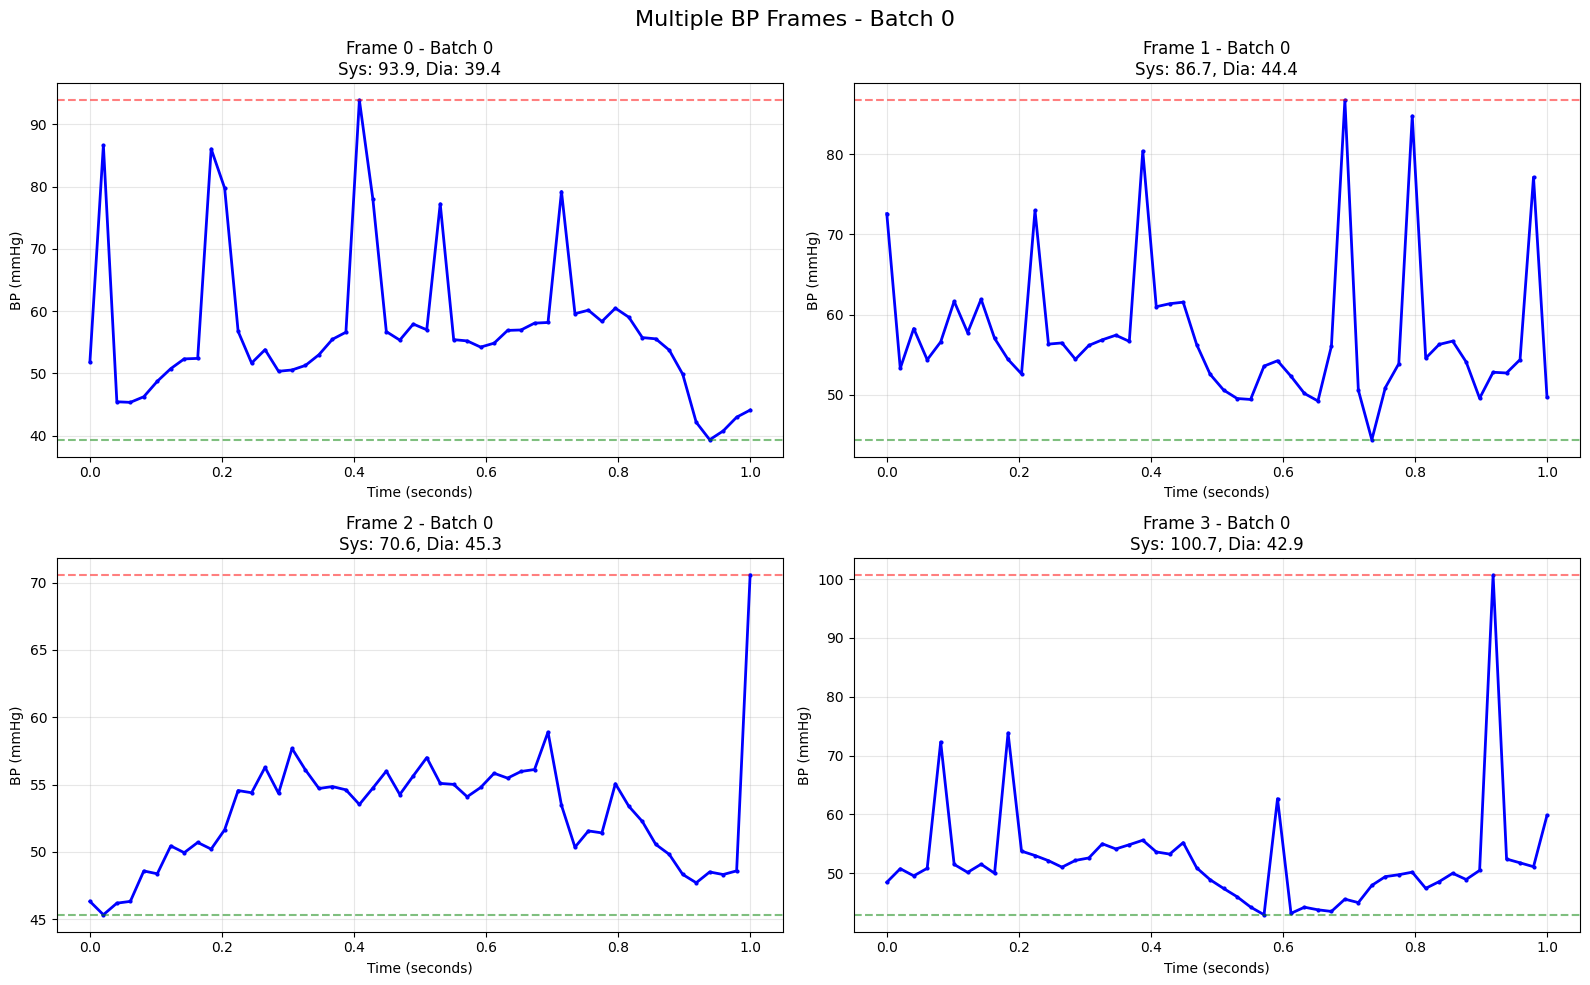

In [4]:
def plot_multiple_bp_frames(bp_data, batch_idx=0, frame_indices=[0, 1, 2, 3], figsize=(16, 10)):
    """Plot multiple BP frames in a grid"""
    
    n_frames = len(frame_indices)
    rows = (n_frames + 1) // 2  # 2 columns
    cols = 2
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for i, frame_idx in enumerate(frame_indices):
        # Calculate start and end indices
        start_idx = frame_idx * FRAME_SIZE
        end_idx = start_idx + FRAME_SIZE
        
        if end_idx <= bp_data.shape[1] and i < len(axes):
            # Extract frame
            bp_frame = bp_data[batch_idx, start_idx:end_idx]
            time_axis = np.linspace(0, 1, FRAME_SIZE)
            
            # Plot
            axes[i].plot(time_axis, bp_frame, 'b-', linewidth=2, marker='o', markersize=2)
            axes[i].grid(True, alpha=0.3)
            axes[i].set_xlabel('Time (seconds)')
            axes[i].set_ylabel('BP (mmHg)')
            axes[i].set_title(f'Frame {frame_idx} - Batch {batch_idx}\nSys: {np.max(bp_frame):.1f}, Dia: {np.min(bp_frame):.1f}')
            
            # Add systolic/diastolic lines
            axes[i].axhline(y=np.max(bp_frame), color='red', linestyle='--', alpha=0.5)
            axes[i].axhline(y=np.min(bp_frame), color='green', linestyle='--', alpha=0.5)
        else:
            axes[i].text(0.5, 0.5, f'Frame {frame_idx}\nnot available', 
                        ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_xticks([])
            axes[i].set_yticks([])
    
    # Hide extra subplots
    for i in range(len(frame_indices), len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle(f'Multiple BP Frames - Batch {batch_idx}', fontsize=16)
    plt.tight_layout()
    plt.show()

# Plot multiple consecutive frames
plot_multiple_bp_frames(bp_data, batch_idx=0, frame_indices=[0, 1, 2, 3])


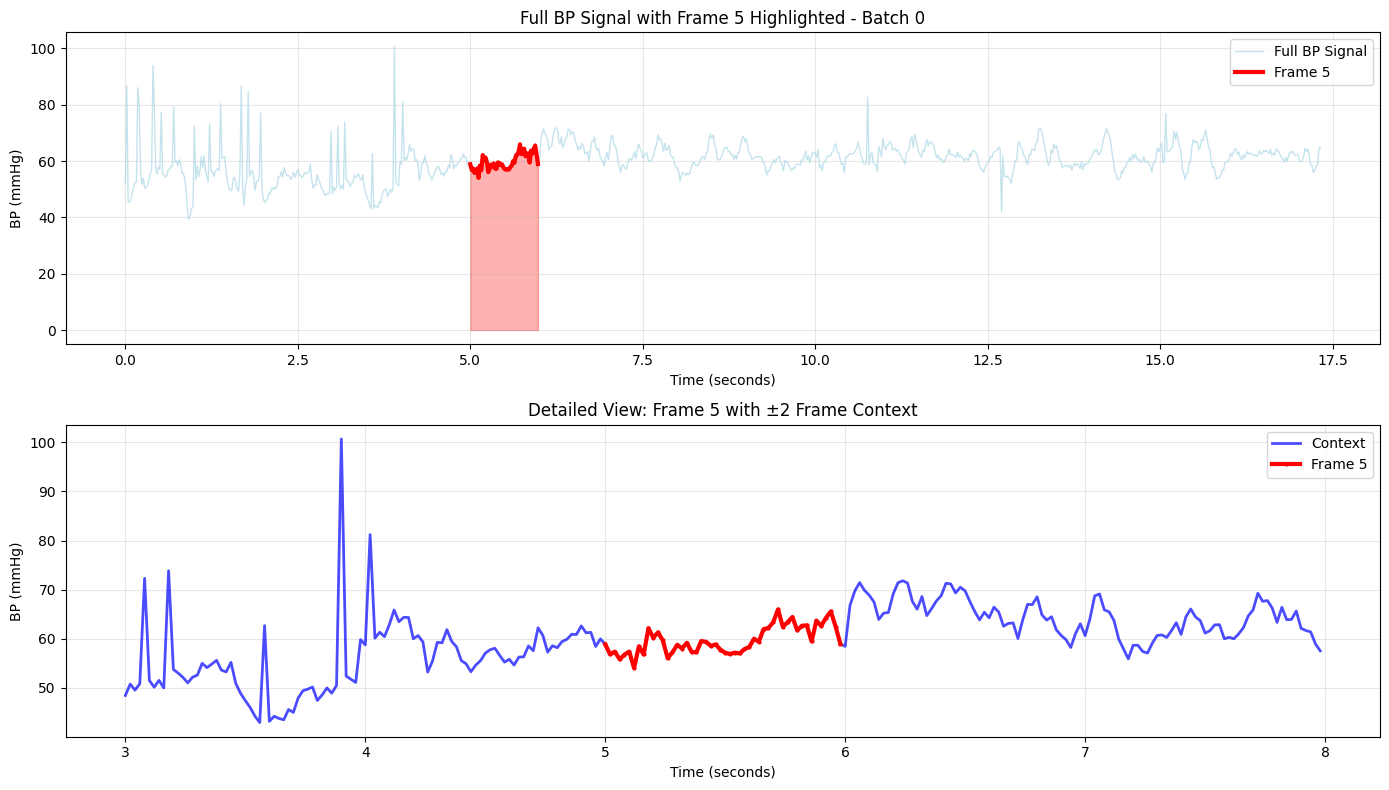

Frame 5 statistics:
  Time range: 5.00 - 5.98 seconds
  Systolic: 66.0 mmHg
  Diastolic: 54.0 mmHg
  Pulse Pressure: 11.9 mmHg


In [5]:
def plot_bp_frame_with_context(bp_data, batch_idx=0, frame_idx=5, context_frames=2, figsize=(14, 8)):
    """Plot a BP frame with surrounding context"""
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize)
    
    # Plot 1: Full signal with frame highlighted
    full_signal = bp_data[batch_idx, :]
    time_full = np.arange(len(full_signal)) / 50.0  # Convert to seconds
    
    ax1.plot(time_full, full_signal, 'lightblue', linewidth=1, alpha=0.7, label='Full BP Signal')
    
    # Highlight the target frame
    start_idx = frame_idx * FRAME_SIZE
    end_idx = start_idx + FRAME_SIZE
    frame_time = np.arange(start_idx, end_idx) / 50.0
    frame_signal = full_signal[start_idx:end_idx]
    
    ax1.plot(frame_time, frame_signal, 'red', linewidth=3, label=f'Frame {frame_idx}')
    ax1.fill_between(frame_time, frame_signal, alpha=0.3, color='red')
    
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('BP (mmHg)')
    ax1.set_title(f'Full BP Signal with Frame {frame_idx} Highlighted - Batch {batch_idx}')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Plot 2: Detailed view of target frame and context
    context_start = max(0, (frame_idx - context_frames) * FRAME_SIZE)
    context_end = min(len(full_signal), (frame_idx + context_frames + 1) * FRAME_SIZE)
    
    context_signal = full_signal[context_start:context_end]
    context_time = np.arange(context_start, context_end) / 50.0
    
    ax2.plot(context_time, context_signal, 'blue', linewidth=2, alpha=0.7, label='Context')
    ax2.plot(frame_time, frame_signal, 'red', linewidth=3, marker='o', markersize=2, label=f'Frame {frame_idx}')
    
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('BP (mmHg)')
    ax2.set_title(f'Detailed View: Frame {frame_idx} with ±{context_frames} Frame Context')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print frame statistics
    systolic = np.max(frame_signal)
    diastolic = np.min(frame_signal)
    print(f"Frame {frame_idx} statistics:")
    print(f"  Time range: {frame_time[0]:.2f} - {frame_time[-1]:.2f} seconds")
    print(f"  Systolic: {systolic:.1f} mmHg")
    print(f"  Diastolic: {diastolic:.1f} mmHg")
    print(f"  Pulse Pressure: {systolic - diastolic:.1f} mmHg")

# Plot frame with context
plot_bp_frame_with_context(bp_data, batch_idx=0, frame_idx=5, context_frames=2)


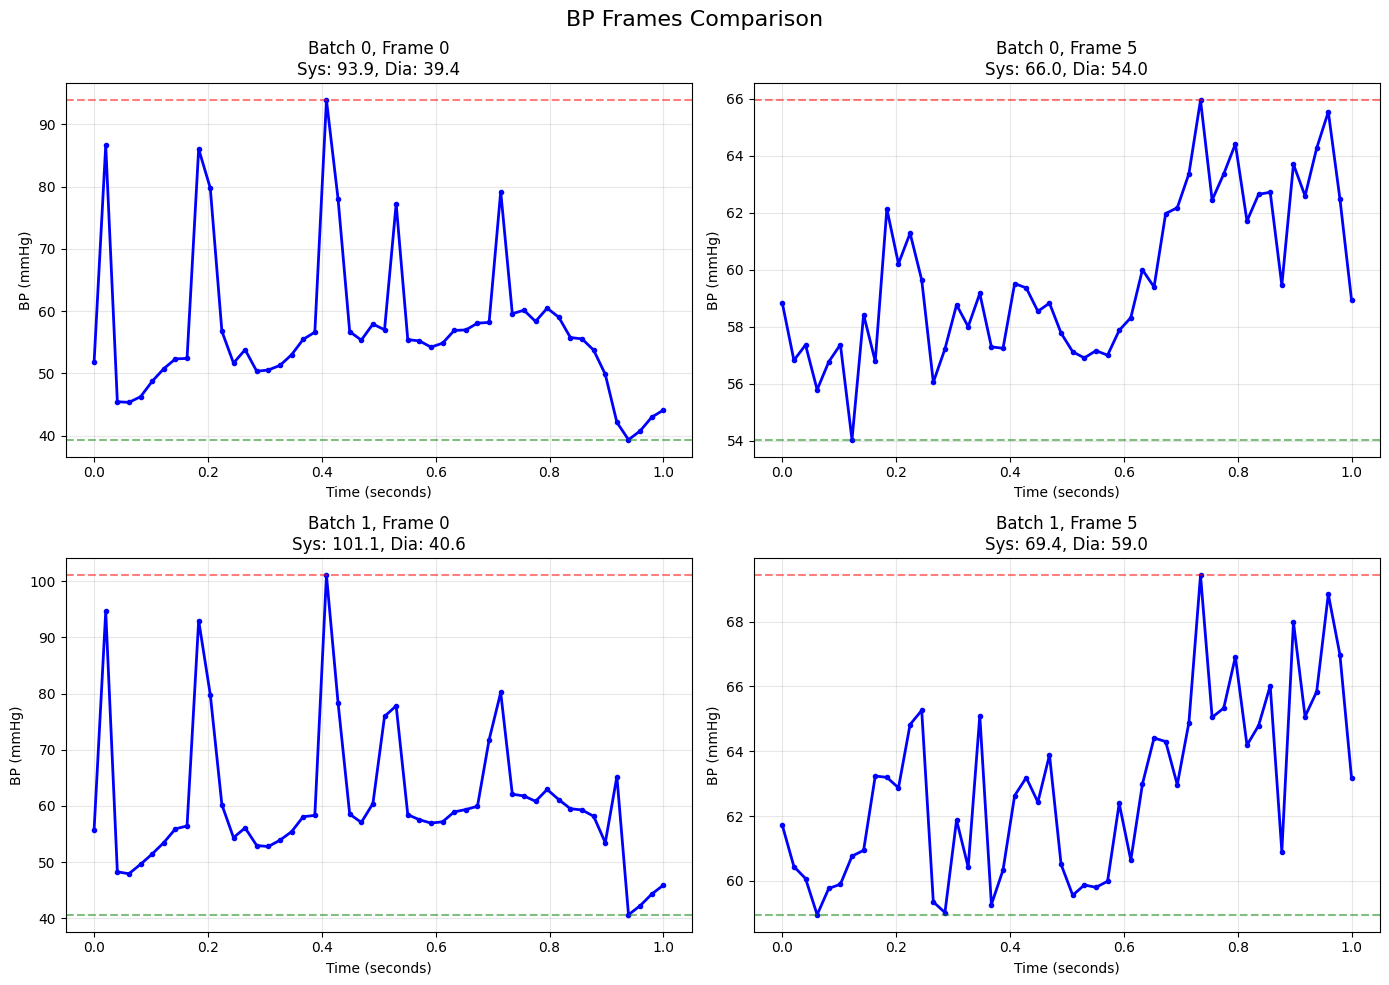

In [6]:
# Simple custom examples - modify as needed

# Example 1: Compare frames from different batches
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

frame_examples = [
    (0, 0),  # batch 0, frame 0
    (0, 5),  # batch 0, frame 5
    (1, 0),  # batch 1, frame 0
    (1, 5),  # batch 1, frame 5
]

for i, (batch_idx, frame_idx) in enumerate(frame_examples):
    if batch_idx < bp_data.shape[0]:
        start_idx = frame_idx * FRAME_SIZE
        end_idx = start_idx + FRAME_SIZE
        
        if end_idx <= bp_data.shape[1]:
            bp_frame = bp_data[batch_idx, start_idx:end_idx]
            time_axis = np.linspace(0, 1, FRAME_SIZE)
            
            axes[i].plot(time_axis, bp_frame, 'b-', linewidth=2, marker='o', markersize=3)
            axes[i].grid(True, alpha=0.3)
            axes[i].set_xlabel('Time (seconds)')
            axes[i].set_ylabel('BP (mmHg)')
            axes[i].set_title(f'Batch {batch_idx}, Frame {frame_idx}\nSys: {np.max(bp_frame):.1f}, Dia: {np.min(bp_frame):.1f}')
            
            # Add reference lines
            axes[i].axhline(y=np.max(bp_frame), color='red', linestyle='--', alpha=0.5)
            axes[i].axhline(y=np.min(bp_frame), color='green', linestyle='--', alpha=0.5)

plt.suptitle('BP Frames Comparison', fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
# Example 2: Analyze frame statistics
def analyze_bp_frame_stats(bp_data, batch_idx=0, frame_idx=0):
    """Analyze statistics of a BP frame"""
    
    start_idx = frame_idx * FRAME_SIZE
    end_idx = start_idx + FRAME_SIZE
    
    if end_idx > bp_data.shape[1]:
        print(f"Frame {frame_idx} is out of bounds")
        return
    
    bp_frame = bp_data[batch_idx, start_idx:end_idx]
    
    # Calculate statistics
    systolic = np.max(bp_frame)
    diastolic = np.min(bp_frame)
    mean_bp = np.mean(bp_frame)
    pulse_pressure = systolic - diastolic
    std_bp = np.std(bp_frame)
    
    # Find peaks (simple peak detection)
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(bp_frame, height=mean_bp)
    valleys, _ = find_peaks(-bp_frame, height=-mean_bp)
    
    print(f"BP Frame {frame_idx} Analysis (Batch {batch_idx}):")
    print(f"  Systolic BP: {systolic:.1f} mmHg")
    print(f"  Diastolic BP: {diastolic:.1f} mmHg")
    print(f"  Mean BP: {mean_bp:.1f} mmHg")
    print(f"  Pulse Pressure: {pulse_pressure:.1f} mmHg")
    print(f"  Standard Deviation: {std_bp:.2f} mmHg")
    print(f"  Number of peaks: {len(peaks)}")
    print(f"  Number of valleys: {len(valleys)}")
    
    # Plot with annotations
    plt.figure(figsize=(12, 6))
    time_axis = np.linspace(0, 1, FRAME_SIZE)
    
    plt.plot(time_axis, bp_frame, 'b-', linewidth=2, marker='o', markersize=3)
    
    # Mark peaks and valleys
    if len(peaks) > 0:
        plt.scatter(time_axis[peaks], bp_frame[peaks], color='red', s=50, zorder=5, label='Peaks')
    if len(valleys) > 0:
        plt.scatter(time_axis[valleys], bp_frame[valleys], color='green', s=50, zorder=5, label='Valleys')
    
    # Add reference lines
    plt.axhline(y=systolic, color='red', linestyle='--', alpha=0.7, label=f'Systolic: {systolic:.1f}')
    plt.axhline(y=diastolic, color='green', linestyle='--', alpha=0.7, label=f'Diastolic: {diastolic:.1f}')
    plt.axhline(y=mean_bp, color='orange', linestyle='--', alpha=0.7, label=f'Mean: {mean_bp:.1f}')
    
    plt.grid(True, alpha=0.3)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Blood Pressure (mmHg)')
    plt.title(f'BP Frame {frame_idx} Analysis - Batch {batch_idx}')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Analyze a specific frame
try:
    analyze_bp_frame_stats(bp_data, batch_idx=0, frame_idx=3)
except ImportError:
    print("scipy not available for peak detection, using simpler analysis")
    # Simple version without peak detection
    frame_idx = 3
    batch_idx = 0
    start_idx = frame_idx * FRAME_SIZE
    end_idx = start_idx + FRAME_SIZE
    bp_frame = bp_data[batch_idx, start_idx:end_idx]
    
    print(f"BP Frame {frame_idx} Simple Analysis:")
    print(f"  Systolic: {np.max(bp_frame):.1f} mmHg")
    print(f"  Diastolic: {np.min(bp_frame):.1f} mmHg")
    print(f"  Mean: {np.mean(bp_frame):.1f} mmHg")
    print(f"  Std: {np.std(bp_frame):.2f} mmHg")
